# Data audit: MISO demand, EIA forecast, temperature

Checks on the two raw files built by `python -m src.build_data`, as pulled on 2026-10-05:
missing hours, duplicated hours around daylight saving time, and outliers.
Numbers in the prose below are from that pull. EIA revises EIA-930 data, so a later pull can shift them slightly.

**Summary**

- 32,972 hourly rows from 2023-01-01 00:00 UTC. No hour is absent from the UTC grid and no hour is duplicated.
- Demand is missing for one full day (2024-07-01, 24 hours). EIA's forecast is missing for five full days. Temperature is complete.
- Nothing looks like a data error. The most extreme hours are heat waves, cold snaps and holidays, so I keep all of them.
- I dropped nothing from the raw files. Session 2 scores every method only on hours where demand, forecast and temperature all exist.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

eia = pd.read_parquet("../data/raw/eia_miso.parquet")
weather = pd.read_parquet("../data/raw/weather_miso.parquet")
eia.head()

,demand_mwh,forecast_mwh
timestamp_utc,,
2023-01-01 00:00:00+00:00,70159.0,71183.0
2023-01-01 01:00:00+00:00,69592.0,70907.0
2023-01-01 02:00:00+00:00,68133.0,70142.0
2023-01-01 03:00:00+00:00,66497.0,68987.0
2023-01-01 04:00:00+00:00,64874.0,67160.0


## Missing hours

First check: is every UTC hour between the first and last row present? Then count missing values inside the rows that exist.

In [2]:
full_grid = pd.date_range(eia.index.min(), eia.index.max(), freq="h")
print("hours in range:", len(full_grid))
print("absent from EIA:", len(full_grid.difference(eia.index)))
print("absent from weather:", len(full_grid.difference(weather.index)))
print()
print(eia.isna().sum())
print(weather.isna().sum())

hours in range: 32972
absent from EIA: 0
absent from weather: 0

demand_mwh       25
forecast_mwh    120
dtype: int64
temp_f_detroit        0
temp_f_chicago        0
temp_f_minneapolis    0
temp_f_st_louis       0
temp_f_mean           0
dtype: int64


In [3]:
def missing_runs(series):
    """Consecutive stretches of missing hours."""
    runs = []
    start = None
    prev = None
    for hour in series[series.isna()].index:
        if start is not None and hour - prev != pd.Timedelta(hours=1):
            runs.append((start, prev))
            start = None
        if start is None:
            start = hour
        prev = hour
    if start is not None:
        runs.append((start, prev))
    table = pd.DataFrame(runs, columns=["first_hour", "last_hour"])
    table["hours"] = (table["last_hour"] - table["first_hour"]) / pd.Timedelta(hours=1) + 1
    return table

print("demand_mwh")
print(missing_runs(eia["demand_mwh"]))
print()
print("forecast_mwh")
print(missing_runs(eia["forecast_mwh"]))

demand_mwh
                 first_hour                 last_hour  hours
0 2024-07-01 06:00:00+00:00 2024-07-02 05:00:00+00:00   24.0
1 2026-10-05 19:00:00+00:00 2026-10-05 19:00:00+00:00    1.0

forecast_mwh
                 first_hour                 last_hour  hours
0 2024-07-02 06:00:00+00:00 2024-07-03 05:00:00+00:00   24.0
1 2026-03-20 06:00:00+00:00 2026-03-21 05:00:00+00:00   24.0
2 2026-04-27 06:00:00+00:00 2026-04-28 05:00:00+00:00   24.0
3 2026-08-02 06:00:00+00:00 2026-08-03 05:00:00+00:00   24.0
4 2026-08-06 06:00:00+00:00 2026-08-07 05:00:00+00:00   24.0


Every gap is a whole day running 06:00 to 05:00 UTC, which is midnight to midnight in Central Standard Time.
That looks like a daily submission that never reached EIA, not scattered bad hours.
The demand gap (2024-07-01) and the first forecast gap (2024-07-02) sit on back to back days.

The last row is the hour of the pull. Its demand is not reported yet, so it is missing until the next pull.

I do not fill these gaps. Interpolating a full day of load would invent a day of data,
and the forecast gaps are the benchmark itself, so filling them would grade EIA on numbers EIA never published.

## Duplicated hours at the DST change

`src/pull_eia.py` asks EIA for `frequency=hourly`, which is UTC. UTC has no daylight saving, so the clock never repeats.
EIA also offers `local-hourly`, where the November fall back hour would appear twice. That is the reason to pull UTC.

In [4]:
print("duplicated UTC hours, EIA:", eia.index.duplicated().sum())
print("duplicated UTC hours, weather:", weather.index.duplicated().sum())

central = eia.index.tz_convert("America/Chicago")
hours_per_day = pd.Series(1, index=central).groupby(central.date).count()
print()
print("Central time days without 24 hours:")
print(hours_per_day[hours_per_day != 24])

duplicated UTC hours, EIA: 0
duplicated UTC hours, weather: 0

Central time days without 24 hours:
2022-12-31     6
2023-03-12    23
2023-11-05    25
2024-03-10    23
2024-11-03    25
2025-03-09    23
2025-11-02    25
2026-03-08    23
2026-10-05    15
dtype: int64


In Central time the spring forward days have 23 hours and the fall back days have 25, as they should.
The first and last dates are short only because the pull starts at midnight UTC and ends at the current hour.

Decision for session 2: keep UTC as the join key, and build hour of day and day of week from America/Chicago,
since most of MISO's load runs on Central clocks.

## Outliers

EIA-930 has known problems with zeros and spikes for some balancing authorities, so I check for values that cannot be real,
then look at the hours furthest from normal and ask whether a real event explains them.

In [5]:
print(eia.describe().round(0))
print()
print("demand at or below zero:", (eia["demand_mwh"] <= 0).sum())
print("forecast at or below zero:", (eia["forecast_mwh"] <= 0).sum())
print()
print(weather.describe().round(1))

       demand_mwh  forecast_mwh
count     32947.0       32852.0
mean      75164.0       76888.0
std       11907.0       12193.0
min       52252.0       53933.0
25%       66988.0       68468.0
50%       72797.0       74458.0
75%       81168.0       82800.0
max      121560.0      127807.0

demand at or below zero: 0
forecast at or below zero: 0

       temp_f_detroit  temp_f_chicago  temp_f_minneapolis  temp_f_st_louis  \
count         32972.0         32972.0             32972.0          32972.0   
mean             52.2            52.7                48.8             59.0   
std              19.5            19.4                23.1             19.4   
min             -10.8           -12.7               -23.5             -6.6   
25%              36.2            37.6                31.7             44.4   
50%              53.6            54.6                51.1             62.3   
75%              68.5            68.6                67.8             74.1   
max             100.0         

In [6]:
# same hour last week, so the daily cycle cancels out
week_ratio = eia["demand_mwh"] / eia["demand_mwh"].shift(168)
print("lowest demand vs same hour last week")
print(week_ratio.nsmallest(5).round(3))
print()
print("highest demand vs same hour last week")
print(week_ratio.nlargest(5).round(3))

lowest demand vs same hour last week
timestamp_utc
2024-09-02 19:00:00+00:00    0.663
2024-09-02 18:00:00+00:00    0.663
2024-09-02 20:00:00+00:00    0.667
2024-09-02 17:00:00+00:00    0.668
2024-09-02 16:00:00+00:00    0.673
Name: demand_mwh, dtype: float64

highest demand vs same hour last week
timestamp_utc
2024-01-16 10:00:00+00:00    1.379
2024-01-16 09:00:00+00:00    1.373
2023-06-03 19:00:00+00:00    1.370
2025-01-08 13:00:00+00:00    1.369
2023-06-03 20:00:00+00:00    1.369
Name: demand_mwh, dtype: float64


In [7]:
forecast_gap = (eia["demand_mwh"] - eia["forecast_mwh"]) / eia["forecast_mwh"]
print("median gap, actual vs forecast:", round(forecast_gap.median() * 100, 1), "%")
print()
print("hours where actual fell furthest below forecast")
print(forecast_gap.nsmallest(5).round(3))
print()
print("hours where actual rose furthest above forecast")
print(forecast_gap.nlargest(5).round(3))

median gap, actual vs forecast: -2.3 %

hours where actual fell furthest below forecast
timestamp_utc
2023-01-02 14:00:00+00:00   -0.129
2023-01-02 13:00:00+00:00   -0.122
2025-12-24 13:00:00+00:00   -0.120
2023-01-02 15:00:00+00:00   -0.120
2023-07-26 21:00:00+00:00   -0.115
dtype: float64

hours where actual rose furthest above forecast
timestamp_utc
2025-01-20 09:00:00+00:00    0.086
2025-01-20 08:00:00+00:00    0.084
2026-01-24 21:00:00+00:00    0.080
2025-01-20 10:00:00+00:00    0.079
2025-01-20 07:00:00+00:00    0.078
dtype: float64


What the extremes turn out to be:

- **Labor Day 2024** (2024-09-02) has the lowest demand against the week before, about 0.66 of it, because the week before was a heat wave.
- **2024-01-16** has the highest, about 1.38, during the January 2024 cold snap.
- The biggest forecast misses are on holidays. EIA's forecast ran 12 to 13% high on 2023-01-02 (the observed New Year holiday)
  and on 2025-12-24. It ran about 8% low on the night of 2025-01-20, another cold snap.
- The overall peak is 121,560 MWh at 2024-08-26 22:00 UTC, a late August heat wave. The floor is about 52,000 MWh on early mornings of
  Christmas and mild spring and fall weekends.

All of these are real demand. Dropping them would remove exactly the hours a forecaster gets judged on, so I keep them.

One thing worth carrying forward: EIA's day ahead forecast runs high. The median hour comes in 2.3% below forecast.
A benchmark with a steady bias is beatable, and session 2 should say how much of any win comes from that bias alone.

## Demand against temperature

The daily correlation between demand and averaged temperature is weak, because the relationship is U shaped:
demand climbs in both cold and hot weather. That is the reason session 2 uses heating and cooling degree hours instead of raw temperature.

daily correlation: 0.34


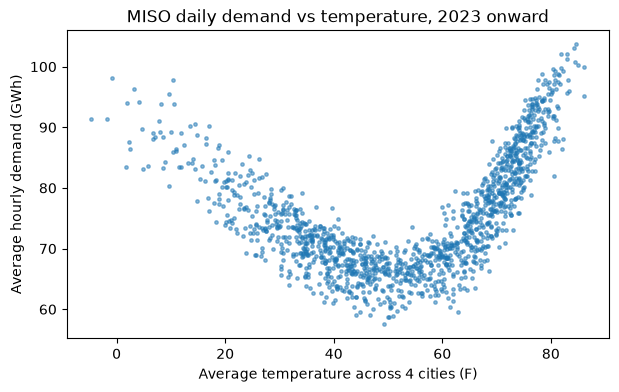

In [8]:
daily = pd.concat([eia["demand_mwh"], weather["temp_f_mean"]], axis=1).resample("D").mean()
print("daily correlation:", round(daily.corr().iloc[0, 1], 2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(daily["temp_f_mean"], daily["demand_mwh"] / 1000, s=6, alpha=0.5)
ax.set_xlabel("Average temperature across 4 cities (F)")
ax.set_ylabel("Average hourly demand (GWh)")
ax.set_title("MISO daily demand vs temperature, 2023 onward")
plt.show()

## What I dropped and why

| Issue | Hours | What I did |
|---|---|---|
| Hours absent from the UTC grid | 0 | Nothing needed |
| Duplicated hours at DST | 0 | Avoided by pulling UTC |
| Demand missing, 2024-07-01 | 24 | Left as missing. Excluded from training targets and scoring |
| EIA forecast missing, 5 days | 120 | Left as missing. Those hours are excluded when comparing methods |
| Current hour, demand not reported yet | 1 | Left as missing. Fills in on the next pull |
| Outliers | 0 | None found. Extremes are heat, cold and holidays |

Two limits this audit cannot fix:

- EIA-930 is preliminary and gets revised. The "actuals" here can change after a later pull.
- Four city temperatures are a rough stand in for a footprint that covers 15 states, and none of the four is in MISO South
  (Louisiana, Arkansas, Mississippi, east Texas). The plain average also gives Minneapolis the same weight as Chicago.